In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Libraries**

In [7]:
import numpy as np

In [8]:
!pip install rasterio
!pip install matplotlib  # Optional for visualization

In [9]:
!pip install dbfread

In [10]:
pip install imagecodecs

In [11]:
!pip install rasterio numpy opencv-python pillow tqdm

# **Rasterize**

In [ ]:
# Class → ID mapping
class_map = {
    'background': 0,
    'builtup': 1,
    'grassland': 2,
    'bare land': 3,
    'forest': 4,
    'shrubland': 5,
    'water body': 6,
    'wetland': 7,
    'permanent ice and snow': 8,
    'other crop': 9,
    'flower seeds': 10,
    'orchards': 11,
    'maize': 12,
    'wheat': 13,
    'rice': 14
}

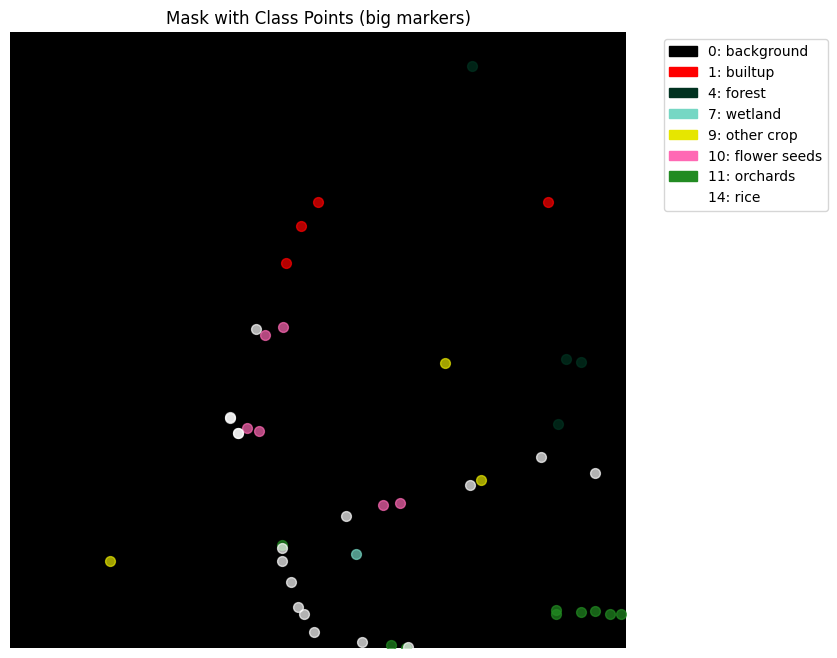

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# === Assume you already have your mask array ===
# mask = ...

classes_with_ids = [
    (0, 'background'),
    (1, 'builtup'),
    (2, 'grassland'),
    (3, 'bare land'),
    (4, 'forest'),
    (5, 'shrubland'),
    (6, 'water body'),
    (7, 'wetland'),
    (8, 'permanent ice and snow'),
    (9, 'other crop'),
    (10, 'flower seeds'),
    (11, 'orchards'),
    (12, 'maize'),
    (13, 'wheat'),
    (14, 'rice')
]

color_map = {
    0:  '#000000',
    1:  '#ff0000',
    2:  '#7CFC00',
    3:  '#e5c07b',
    4:  '#013220',
    5:  '#BDB76B',
    6:  '#4a90e2',
    7:  '#76d7c4',
    8:  '#ffffff',
    9:  '#e6e600',
    10: '#ff69b4',
    11: '#228B22',
    12: '#ffd700',
    13: '#c2b280',
    14: '#ffffff',
}

# --- Plot ---
plt.figure(figsize=(8,8))
plt.imshow(np.zeros_like(mask), cmap="gray")  # empty background

for class_id, name in classes_with_ids:
    ys, xs = np.where(mask == class_id)
    if len(xs) > 0 and class_id != 0:  # skip background
        plt.scatter(xs, ys, s=50, c=color_map[class_id], label=f"{class_id}: {name}", alpha=0.7)

# Legend
handles = [mpatches.Patch(color=color_map[i], label=f"{i}: {name}")
           for i, name in classes_with_ids if i in np.unique(mask)]
plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Mask with Class Points (big markers)")
plt.axis("off")
plt.show()


rasterize all

In [ ]:
import os
import rasterio
from rasterio import features
import geopandas as gpd
import numpy as np
from glob import glob
from tqdm import tqdm   #  progress bar

# === Input directories ===
image_dir     = "/content/drive/MyDrive/Images"
shapefile_dir = "/content/drive/MyDrive/Masks"
output_dir    = "/content/drive/MyDrive/Raster_masks_all"

os.makedirs(output_dir, exist_ok=True)

# === Class map ===
class_map = {
    'background': 0, 'builtup': 1, 'grassland': 2, 'bare land': 3, 'forest': 4,
    'shrubland': 5, 'water body': 6, 'wetland': 7, 'permanent ice and snow': 8,
    'other crop': 9, 'flower seeds': 10, 'orchards': 11, 'maize': 12,
    'wheat': 13, 'rice': 14
}

# === Process each shapefile ===
shapefiles = sorted(glob(os.path.join(shapefile_dir, "*.shp")))
print(f"Found {len(shapefiles)} shapefiles")

for shp_path in tqdm(shapefiles, desc="Rasterizing masks", ncols=100):
    name = os.path.splitext(os.path.basename(shp_path))[0]
    img_path = os.path.join(image_dir, name + ".tif")
    out_path = os.path.join(output_dir, name + ".tif")

    if not os.path.exists(img_path):
        tqdm.write(f" Skipping {name}: matching image not found")
        continue

    # --- 1. Read reference image ---
    with rasterio.open(img_path) as src:
        ref_meta = src.meta.copy()
        ref_crs = src.crs
        ref_transform = src.transform
        ref_shape = (src.height, src.width)

    # --- 2. Read shapefile ---
    gdf = gpd.read_file(shp_path)

    if "Classes" not in gdf.columns:
        tqdm.write(f" Skipping {name}: no 'Classes' column in shapefile")
        continue

    # Reproject if CRS mismatch
    if gdf.crs != ref_crs:
        gdf = gdf.to_crs(ref_crs)

    # Map classes → IDs
    gdf["class_id"] = gdf["Classes"].str.lower().map(class_map)
    gdf = gdf.dropna(subset=["class_id"])
    gdf["class_id"] = gdf["class_id"].astype(np.uint8)

    if gdf.empty:
        tqdm.write(f" Skipping {name}: no valid polygons after mapping")
        continue

    # --- 3. Rasterize ---
    shapes = ((geom, val) for geom, val in zip(gdf.geometry, gdf["class_id"]))
    mask = features.rasterize(
        shapes=shapes,
        out_shape=ref_shape,
        transform=ref_transform,
        fill=0,
        dtype="uint8"
    )

    # --- 4. Save rasterized mask ---
    mask_meta = ref_meta.copy()
    mask_meta.update({"count": 1, "dtype": "uint8"})
    with rasterio.open(out_path, "w", **mask_meta) as dst:
        dst.write(mask, 1)

    tqdm.write(f" Saved: {out_path}, Classes: {np.unique(mask)}")

print(" All masks rasterized and saved.")


Found 152 shapefiles


Rasterizing masks:   1%|▎                                           | 1/152 [00:05<14:34,  5.79s/it]

 Saved: /content/drive/MyDrive/Raster_masks_all/BM01_01.tif, Classes: [0 1 4]


Rasterizing masks:   1%|▌                                           | 2/152 [00:10<12:43,  5.09s/it]

 Saved: /content/drive/MyDrive/Raster_masks_all/BM01_02.tif, Classes: [ 0  4 14]


...

 Saved: /content/drive/MyDrive/Raster_masks_all/BM66_04.tif, Classes: [0 2 3 4 5 8]


Rasterizing masks:  99%|█████████████████████████████████████████▋| 151/152 [10:14<00:03,  3.92s/it]

 Saved: /content/drive/MyDrive/Raster_masks_all/BM66_05.tif, Classes: [0 2 3 4 7 8]


Rasterizing masks: 100%|██████████████████████████████████████████| 152/152 [10:18<00:00,  4.07s/it]

 Saved: /content/drive/MyDrive/Raster_masks_all/BM66_07.tif, Classes: [0 2 4]
 All masks rasterized and saved.


In [ ]:
import os
import numpy as np
import tifffile as tiff
from tqdm import tqdm

# === Input paths ===
image_path = "/content/drive/MyDrive/Images/BM01_02.tif"
mask_path  = "/content/drive/MyDrive/Raster_masks_all/BM01_02.tif"

# === Output paths ===
out_img_dir  = "/content/drive/MyDrive/Patch8/Images"
out_mask_dir = "/content/drive/MyDrive/Patch8/Masks"
os.makedirs(out_img_dir, exist_ok=True)
os.makedirs(out_mask_dir, exist_ok=True)

# === Parameters ===
patch_size = 8
patch_id = 1

# === Load data ===
image = tiff.imread(image_path).astype(np.float32)   # (H, W, C)
mask  = tiff.imread(mask_path).astype(np.uint8)      # (H, W)

H, W = mask.shape

def extract_patch(y, x):
    """Extract 8x8 patch from image and mask at (y, x)."""
    img_patch = image[y:y+patch_size, x:x+patch_size, :]
    msk_patch = mask[y:y+patch_size, x:x+patch_size]
    return img_patch, msk_patch

def is_valid(msk_patch):
    """Check mask patch: must contain exactly one non-zero class."""
    classes = np.unique(msk_patch)
    non_zero = [c for c in classes if c != 0]
    return len(non_zero) == 1, non_zero

# === Patching with progress bar ===
stride = patch_size
total_patches = (H // patch_size) * (W // patch_size)

with tqdm(total=total_patches, desc="Extracting 8x8 patches", ncols=100) as pbar:
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):

            img_patch, msk_patch = extract_patch(y, x)

            if img_patch.shape[0] != patch_size or img_patch.shape[1] != patch_size:
                pbar.update(1)
                continue

            if np.all(msk_patch == 0):  # skip background-only
                pbar.update(1)
                continue

            valid, non_zero = is_valid(msk_patch)

            if not valid:
                found = False
                for dy, dx in [(-1,0), (1,0), (0,-1), (0,1)]:
                    ny, nx = y+dy, x+dx
                    if ny < 0 or nx < 0 or ny+patch_size>H or nx+patch_size>W:
                        continue
                    img_patch, msk_patch = extract_patch(ny, nx)
                    valid, non_zero = is_valid(msk_patch)
                    if valid:
                        found = True
                        break
                if not found:
                    pbar.update(1)
                    continue

            # Save patch
            img_out = os.path.join(out_img_dir, f"{patch_id}.tif")
            msk_out = os.path.join(out_mask_dir, f"{patch_id}.tif")
            tiff.imwrite(img_out, img_patch.astype(np.float32))
            tiff.imwrite(msk_out, msk_patch.astype(np.uint8))
            patch_id += 1

            pbar.update(1)

print(f"\n Finished. Total patches saved: {patch_id-1}")


Extracting 8x8 patches: 100%|███████████████████████████| 746496/746496 [00:05<00:00, 132670.88it/s]


 Finished. Total patches saved: 18


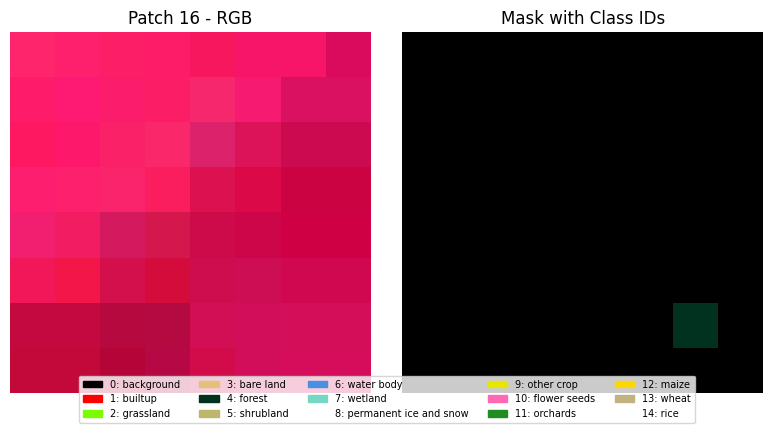

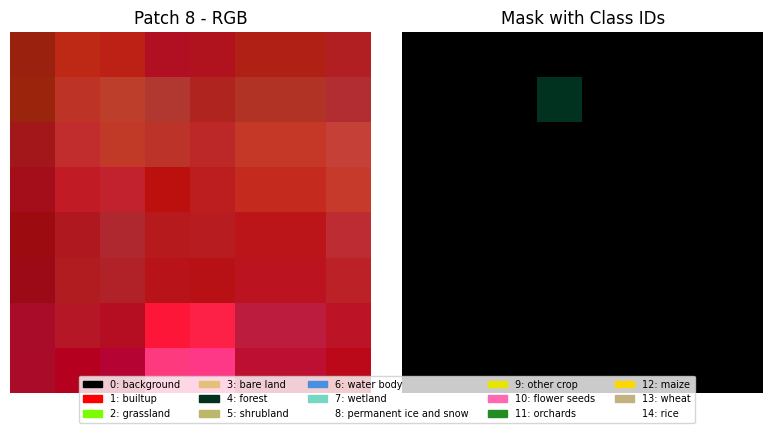

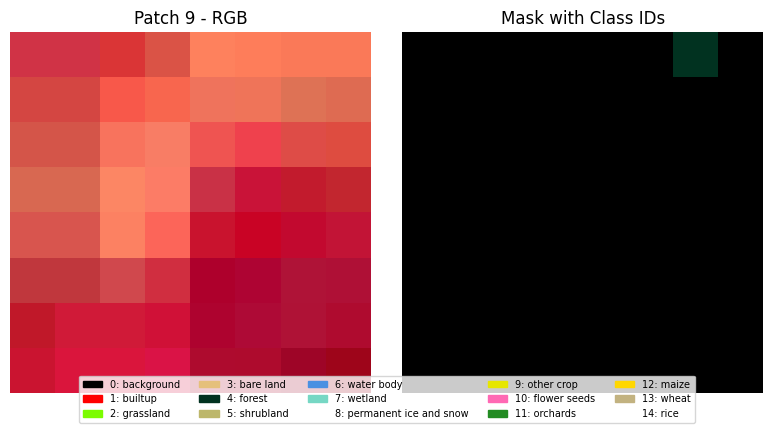

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import tifffile as tiff

# === Paths ===
out_img_dir  = "/content/drive/MyDrive/Patch8/Images"
out_mask_dir = "/content/drive/MyDrive/Patch8/Masks"

# === Class definitions & colormap ===
classes_with_ids = [
    (0, 'background'), (1, 'builtup'), (2, 'grassland'), (3, 'bare land'),
    (4, 'forest'), (5, 'shrubland'), (6, 'water body'), (7, 'wetland'),
    (8, 'permanent ice and snow'), (9, 'other crop'), (10, 'flower seeds'),
    (11, 'orchards'), (12, 'maize'), (13, 'wheat'), (14, 'rice')
]

color_map = {
    0:  '#000000', 1:  '#ff0000', 2:  '#7CFC00', 3:  '#e5c07b',
    4:  '#013220', 5:  '#BDB76B', 6:  '#4a90e2', 7:  '#76d7c4',
    8:  '#ffffff', 9:  '#e6e600', 10: '#ff69b4', 11: '#228B22',
    12: '#ffd700', 13: '#c2b280', 14: '#ffffff',
}

# build a ListedColormap from color_map
cmap = mcolors.ListedColormap([color_map[i] for i, _ in classes_with_ids])
bounds = list(color_map.keys()) + [max(color_map.keys()) + 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# === Pick 3 random patches ===
mask_files = sorted(os.listdir(out_mask_dir))
sample_masks = random.sample(mask_files, 3)

for fname in sample_masks:
    patch_id = os.path.splitext(fname)[0]

    img_patch = tiff.imread(os.path.join(out_img_dir, fname.replace(".tif", ".tif")))
    msk_patch = tiff.imread(os.path.join(out_mask_dir, fname))

    # Normalize image for RGB display (bands 4,3,2 if available, else first 3)
    if img_patch.ndim == 3 and img_patch.shape[2] >= 4:
        rgb = img_patch[..., [3, 2, 1]]
    else:
        rgb = img_patch[..., :3]
    rgb = (rgb - np.min(rgb)) / (np.ptp(rgb) + 1e-6)

    # Prepare figure
    fig, axs = plt.subplots(1, 2, figsize=(8,4))

    axs[0].imshow(rgb)
    axs[0].set_title(f"Patch {patch_id} - RGB")
    axs[0].axis("off")

    # Mask with custom colormap (ensures 0=black)
    axs[1].imshow(msk_patch, cmap=cmap, norm=norm)
    axs[1].set_title("Mask with Class IDs")
    axs[1].axis("off")

    # Legend
    handles = [mpatches.Patch(color=color_map[i], label=f"{i}: {name}")
               for i, name in classes_with_ids]
    fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=7, bbox_to_anchor=(0.5, -0.05))

    plt.tight_layout()
    plt.show()


Patchin all

In [ ]:
import os
import numpy as np
import tifffile as tiff
from tqdm import tqdm

# === Input folders (all full images & masks) ===
image_dir = "/content/drive/MyDrive/Images"
mask_dir  = "/content/drive/MyDrive/Raster_masks_all"

# === Output folders ===
out_img_dir  = "/content/drive/MyDrive/Patch8/Images"
out_mask_dir = "/content/drive/MyDrive/Patch8/Masks"
os.makedirs(out_img_dir, exist_ok=True)
os.makedirs(out_mask_dir, exist_ok=True)

# === Parameters ===
patch_size = 8
stride = patch_size   # you can change to overlap patches
patch_id = 1

# === Process each pair ===
for fname in sorted(os.listdir(image_dir)):
    if not fname.endswith(".tif"):
        continue

    image_path = os.path.join(image_dir, fname)
    mask_path  = os.path.join(mask_dir, fname)

    if not os.path.exists(mask_path):
        print(f" Skipping {fname}, no matching mask found.")
        continue

    print(f"\n Processing {fname} ...")

    # Load image & mask
    image = tiff.imread(image_path).astype(np.float32)   # (H, W, C)
    mask  = tiff.imread(mask_path).astype(np.uint8)      # (H, W)
    H, W = mask.shape

    def extract_patch(y, x):
        img_patch = image[y:y+patch_size, x:x+patch_size, :]
        msk_patch = mask[y:y+patch_size, x:x+patch_size]
        return img_patch, msk_patch

    def is_valid(msk_patch):
        classes = np.unique(msk_patch)
        non_zero = [c for c in classes if c != 0]
        return len(non_zero) == 1, non_zero

    total_patches = (H // patch_size) * (W // patch_size)

    with tqdm(total=total_patches, desc=f"Extracting {fname}", ncols=100) as pbar:
        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):

                img_patch, msk_patch = extract_patch(y, x)

                if img_patch.shape[0] != patch_size or img_patch.shape[1] != patch_size:
                    pbar.update(1)
                    continue

                if np.all(msk_patch == 0):  # skip background-only
                    pbar.update(1)
                    continue

                valid, non_zero = is_valid(msk_patch)

                if not valid:
                    found = False
                    for dy, dx in [(-1,0), (1,0), (0,-1), (0,1)]:
                        ny, nx = y+dy, x+dx
                        if ny < 0 or nx < 0 or ny+patch_size>H or nx+patch_size>W:
                            continue
                        img_patch, msk_patch = extract_patch(ny, nx)
                        valid, non_zero = is_valid(msk_patch)
                        if valid:
                            found = True
                            break
                    if not found:
                        pbar.update(1)
                        continue

                # Save patch
                img_out = os.path.join(out_img_dir, f"{patch_id}.tif")
                msk_out = os.path.join(out_mask_dir, f"{patch_id}.tif")
                tiff.imwrite(img_out, img_patch.astype(np.float32))
                tiff.imwrite(msk_out, msk_patch.astype(np.uint8))
                patch_id += 1

                pbar.update(1)

print(f"\n  Finished. Total patches saved: {patch_id-1}")



 Processing BM01_01.tif ...


Extracting BM01_01.tif: 100%|████████████████████████████| 746496/746496 [00:21<00:00, 34894.41it/s]



 Processing BM01_02.tif ...


Extracting BM01_02.tif: 100%|████████████████████████████| 746496/746496 [00:13<00:00, 53735.15it/s]



 Processing BM01_03.tif ...


...


 Processing BM66_05.tif ...


Extracting BM66_05.tif: 100%|███████████████████████████| 746496/746496 [00:04<00:00, 155000.67it/s]



 Processing BM66_07.tif ...


Extracting BM66_07.tif: 100%|███████████████████████████| 423360/423360 [00:02<00:00, 157612.34it/s]


  Finished. Total patches saved: 4500


In [ ]:
import os
import numpy as np
import tifffile as tiff

# === Path to patched masks ===
out_mask_dir = "/content/drive/MyDrive/Patch8/Masks"

all_classes = set()

# Loop over all patch masks
for fname in os.listdir(out_mask_dir):
    if not fname.endswith(".tif"):
        continue
    mask = tiff.imread(os.path.join(out_mask_dir, fname))
    classes = np.unique(mask)
    all_classes.update(classes.tolist())

print(" Classes present in all patched masks:", sorted(all_classes))


 Classes present in all patched masks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


In [ ]:
import os
import numpy as np
import tifffile as tiff
from sklearn.model_selection import train_test_split

# === Paths ===
out_img_dir  = "/content/drive/MyDrive/Patch8/Images"
out_mask_dir = "/content/drive/MyDrive/Patch8/Masks"

# === Collect all patch file names ===
img_files = sorted([f for f in os.listdir(out_img_dir) if f.endswith(".tif")])
msk_files = sorted([f for f in os.listdir(out_mask_dir) if f.endswith(".tif")])

assert len(img_files) == len(msk_files), "Mismatch between images and masks!"
print(f"Total patches found: {len(img_files)}")

# === Split into train (70%), val (20%), test (10%) ===
train_imgs, test_imgs, train_msks, test_msks = train_test_split(
    img_files, msk_files, test_size=0.30, random_state=42
)
val_imgs, test_imgs, val_msks, test_msks = train_test_split(
    test_imgs, test_msks, test_size=1/3, random_state=42
)

print(f"Training patches:   {len(train_imgs)}")
print(f"Validation patches: {len(val_imgs)}")
print(f"Test patches:       {len(test_imgs)}")

# === Load into arrays ===
def load_patches(img_list, msk_list):
    X, Y = [], []
    for imf, msf in zip(img_list, msk_list):
        img = tiff.imread(os.path.join(out_img_dir, imf)).astype(np.float32)
        msk = tiff.imread(os.path.join(out_mask_dir, msf)).astype(np.uint8)
        X.append(img)
        Y.append(msk)
    return np.array(X), np.array(Y)

X_train, Y_train = load_patches(train_imgs, train_msks)
X_val, Y_val     = load_patches(val_imgs, val_msks)
X_test, Y_test   = load_patches(test_imgs, test_msks)

# === Print dataset shapes ===
print("\nDataset shapes:")
print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val:  ", X_val.shape,   "Y_val:  ", Y_val.shape)
print("X_test: ", X_test.shape,  "Y_test: ", Y_test.shape)


Total patches found: 4500
Training patches:   3150
Validation patches: 900
Test patches:       450

Dataset shapes:
X_train: (3150, 8, 8, 23) Y_train: (3150, 8, 8)
X_val:   (900, 8, 8, 23) Y_val:   (900, 8, 8)
X_test:  (450, 8, 8, 23) Y_test:  (450, 8, 8)


In [ ]:
np.save("/content/drive/MyDrive/Patch8/X_train", X_train)
np.save("/content/drive/MyDrive/Patch8/Y_train", Y_train)
np.save("/content/drive/MyDrive/Patch8/X_val", X_val)
np.save("/content/drive/MyDrive/Patch8/Y_val", Y_val)
np.save("/content/drive/MyDrive/Patch8/X_test", X_test)
np.save("/content/drive/MyDrive/Patch8/Y_test", Y_test)

In [12]:
X_train = np.load("/content/drive/MyDrive/Patch8/X_train.npy")
Y_train = np.load("/content/drive/MyDrive/Patch8/Y_train.npy")
X_val = np.load("/content/drive/MyDrive/Patch8/X_val.npy")
Y_val = np.load("/content/drive/MyDrive/Patch8/Y_val.npy")
X_test = np.load("/content/drive/MyDrive/Patch8/X_test.npy")
Y_test = np.load("/content/drive/MyDrive/Patch8/Y_test.npy")

In [13]:
print(X_train.shape)
print(Y_train.shape)
print(Y_train.dtype)
print(np.unique(Y_train))

(3150, 8, 8, 23)
(3150, 8, 8)
uint8
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [14]:
Y_train2 = []

for i in range(Y_train.shape[0]) :
  Y_train2.append(np.unique(Y_train[i])[1])

In [15]:
import numpy as np

Y_train2_array = np.array(Y_train2).reshape(-1, 1)  #Converting to 2D
np.save('Y_train2_array.npy', Y_train2_array)
print(Y_train2_array.shape)

(3150, 1)


In [16]:
Y_val2 = []

for i in range(Y_val.shape[0]) :
  Y_val2.append(np.unique(Y_val[i])[1])

  Y_test2 = []

for i in range(Y_test.shape[0]) :
  Y_test2.append(np.unique(Y_test[i])[1])

In [17]:
import numpy as np

Y_val2_array = np.array(Y_val2).reshape(-1, 1)  #Converting to 2D
np.save('Y_val2_array.npy', Y_val2_array)
print(Y_val2_array.shape)


Y_test2_array = np.array(Y_test2).reshape(-1, 1)  #Converting to 2D
np.save('Y_test2_array.npy', Y_test2_array)
print(Y_test2_array.shape)

(900, 1)
(450, 1)


In [18]:
print("Label shape:", Y_train2_array.shape)
print("Label dtype:", Y_train2_array.dtype)
print("Unique values:", np.unique(Y_train2_array))

Label shape: (3150, 1)
Label dtype: uint8
Unique values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]


# **Training Phase**

In [19]:
import tensorflow as tf
from tensorflow.keras import backend as K

def f1_score(y_true, y_pred):
    y_pred = tf.argmax(y_pred, axis=-1)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true = tf.cast(y_true, tf.float32)

    tp = K.sum(K.cast(y_true * y_pred, 'float'), axis=0)
    fp = K.sum(K.cast((1 - y_true) * y_pred, 'float'), axis=0)
    fn = K.sum(K.cast(y_true * (1 - y_pred), 'float'), axis=0)

    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())

    f1 = 2 * precision * recall / (precision + recall + K.epsilon())
    f1 = tf.where(tf.math.is_nan(f1), tf.zeros_like(f1), f1)
    return K.mean(f1)

**Unet++**

In [20]:
import numpy as np
from collections import Counter

# Make sure Y_train is 1D (class labels per sample)
Y_train_flat = np.array(Y_train2_array).flatten()

# Count samples per class
class_counts = Counter(Y_train_flat)
total = len(Y_train_flat)
num_classes = len(class_counts)

# Compute weights (inverse frequency)
class_weights = {
    cls: total / (num_classes * count)
    for cls, count in class_counts.items()
}

# (Optional) normalize so average weight ≈ 1
avg_weight = np.mean(list(class_weights.values()))
class_weights = {cls: w / avg_weight for cls, w in class_weights.items()}

print("Class Weights:")
for cls, w in sorted(class_weights.items()):
    print(f"  Class {cls}: {w:.4f}")

Class Weights:
  Class 1: 0.6803
  Class 2: 2.2795
  Class 3: 0.7598
  Class 4: 0.2134
  Class 5: 2.2402
  Class 6: 0.4191
  Class 7: 0.7300
  Class 8: 0.8548
  Class 9: 0.4165
  Class 10: 0.3323
  Class 11: 0.3640
  Class 12: 3.0217
  Class 13: 0.6732
  Class 14: 1.0151


In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models
tf.compat.v1.enable_eager_execution()

def build_unetplusplus_classifier(input_shape=(8, 8, 23), num_classes=15):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x0_0 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x0_0 = layers.Conv2D(32, 3, activation='relu', padding='same')(x0_0)
    p0 = layers.MaxPooling2D(pool_size=(2, 2))(x0_0)

    x1_0 = layers.Conv2D(64, 3, activation='relu', padding='same')(p0)
    x1_0 = layers.Conv2D(64, 3, activation='relu', padding='same')(x1_0)
    p1 = layers.MaxPooling2D(pool_size=(2, 2))(x1_0)

    x2_0 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    x2_0 = layers.Conv2D(128, 3, activation='relu', padding='same')(x2_0)

    # Decoder - Dense skip connections
    x1_1 = layers.Concatenate()([x1_0, layers.UpSampling2D()(x2_0)])
    x1_1 = layers.Conv2D(64, 3, activation='relu', padding='same')(x1_1)
    x1_1 = layers.Conv2D(64, 3, activation='relu', padding='same')(x1_1)

    x0_1 = layers.Concatenate()([x0_0, layers.UpSampling2D()(x1_0)])
    x0_1 = layers.Conv2D(32, 3, activation='relu', padding='same')(x0_1)
    x0_1 = layers.Conv2D(32, 3, activation='relu', padding='same')(x0_1)

    x0_2 = layers.Concatenate()([x0_0, x0_1, layers.UpSampling2D()(x1_1)])
    x0_2 = layers.Conv2D(32, 3, activation='relu', padding='same')(x0_2)
    x0_2 = layers.Conv2D(32, 3, activation='relu', padding='same')(x0_2)

    # Classification head
    gap = layers.GlobalAveragePooling2D()(x0_2)
    output = layers.Dense(num_classes, activation='softmax')(gap)  # Fixed to 15 classes

    model = models.Model(inputs=inputs, outputs=output)
    return model


In [22]:
# Build and compile the model
model = build_unetplusplus_classifier()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8, 8, 23)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 8, 8, 32)  │      6,656 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 32)  │      9,248 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 4, 4, 32)  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 4, 4, 64)  │     18,496 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 4, 4, 64)  │     36,928 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 2, 2, 64)  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 2, 2, 128) │     73,856 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 2, 2, 128) │    147,584 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 4, 4, 128) │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 8, 8, 64)  │          0 │ conv2d_3[0][0]    │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 4, 4, 192) │          0 │ conv2d_3[0][0],   │
│ (Concatenate)       │                   │            │ up_sampling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 8, 8, 96)  │          0 │ conv2d_1[0][0],   │
│ (Concatenate)       │                   │            │ up_sampling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 4, 4, 64)  │    110,656 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 32)  │     27,680 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 4, 4, 64)  │     36,928 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 32)  │      9,248 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 8, 8, 64)  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8, 8, 128) │          0 │ conv2d_1[0][0],   │
│ (Concatenate)       │                   │            │ conv2d_9[0][0],   │
│                     │                   │            │ up_sampling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 8, 8, 32)  │     36,896 │ concatenate_2[0]

 Total params: 523,919 (2.00 MB)

 Trainable params: 523,919 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
from tensorflow.keras.callbacks import ModelCheckpoint
import os
# Checkpoint for saving the weights"""
# path_dic_w =

save_dir = "/content/drive/MyDrive/Models/Model_(UnetPlusPlus)"
os.makedirs(save_dir, exist_ok=True)

# Define the full path for the model file
checkpoint_path = os.path.join(save_dir, 'unetplus_epoch_{epoch:02d}.h5')

# Now you can safely use it in the callback
callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,
    save_best_only=False,
    monitor='val_loss',
    mode='min',
    verbose=1
)
# Create a callback that saves the model's weights at every epoch"""
callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 save_weights_only=False,
                                                 save_best_only=False,
                                                 monitor="val_loss",
                                                 mode = "min",
                                                 verbose=1)

"""# Create a callback to reduce the learning rate using the ReduceLROnPlateau function"""
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",
                                                 factor=0.33,
                                                 patience=10,
                                                 mode="min")

early_stop =tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 15,
                          verbose = 1,
                          restore_best_weights = False)

"""# Compile the checkpoints and other settings as a callback"""
callback_list = [callback,reduce_lr] #,early_stop]

In [25]:
history = model.fit(
    X_train, Y_train2_array,
    validation_data=(X_val, Y_val2_array),
    epochs=80,
    batch_size=32,
    verbose=1,
    class_weight=class_weights,
    callbacks=callback_list
)

Epoch 1/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.0818 - loss: 2.6982
Epoch 1: saving model to /content/drive/MyDrive/Models/Model_(UnetPlusPlus)/unetplus_epoch_01.h5


99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - accuracy: 0.0825 - loss: 2.6909 - val_accuracy: 0.2200 - val_loss: 2.4291 - learning_rate: 0.0010
Epoch 2/80
97/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3115 - loss: 1.1950
Epoch 2: saving model to /content/drive/MyDrive/Models/Model_(UnetPlusPlus)/unetplus_epoch_02.h5


99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3117 - loss: 1.1935 - val_accuracy: 0.2311 - val_loss: 1.9346 - learning_rate: 0.0010
Epoch 3/80
98/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2577 - loss: 1.3585
Epoch 3: saving model to /content/drive/MyDrive/Models/Model_(UnetPlusPlus)/unetplus_epoch_03.h5


99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.2579 - loss: 1.3574 - val_accuracy: 0.3233 - val_loss: 1.9834 - learning_rate: 0.0010
Epoch 4/80
89/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3215 - loss: 1.0906
Epoch 4: saving model to /content/drive/MyDrive/Models/Model_(UnetPlusPlus)/unetplus_epoch_04.h5


99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3216 - loss: 1.0891 - val_accuracy: 0.3933 - val_loss: 1.9414 - learning_rate: 0.0010
Epoch 5/80
92/99 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3671 - loss: 1.0385
Epoch 5: saving model to /content/drive/MyDrive/Models/Model_(UnetPlusPlus)/unetplus_epoch_05.h5


...

99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8307 - loss: 0.2725 - val_accuracy: 0.6411 - val_loss: 1.2969 - learning_rate: 3.5937e-05
Epoch 77/80
95/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8209 - loss: 0.2820
Epoch 77: saving model to /content/drive/MyDrive/Models/Model_(UnetPlusPlus)/unetplus_epoch_77.h5


99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8206 - loss: 0.2816 - val_accuracy: 0.6378 - val_loss: 1.3135 - learning_rate: 3.5937e-05
Epoch 78/80
94/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8297 - loss: 0.2550
Epoch 78: saving model to /content/drive/MyDrive/Models/Model_(UnetPlusPlus)/unetplus_epoch_78.h5


99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8290 - loss: 0.2559 - val_accuracy: 0.6344 - val_loss: 1.3155 - learning_rate: 3.5937e-05
Epoch 79/80
97/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8170 - loss: 0.2696
Epoch 79: saving model to /content/drive/MyDrive/Models/Model_(UnetPlusPlus)/unetplus_epoch_79.h5


99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8171 - loss: 0.2696 - val_accuracy: 0.6322 - val_loss: 1.3291 - learning_rate: 3.5937e-05
Epoch 80/80
97/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8192 - loss: 0.2702
Epoch 80: saving model to /content/drive/MyDrive/Models/Model_(UnetPlusPlus)/unetplus_epoch_80.h5


99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8192 - loss: 0.2701 - val_accuracy: 0.6400 - val_loss: 1.3297 - learning_rate: 3.5937e-05


# **Evaluation**

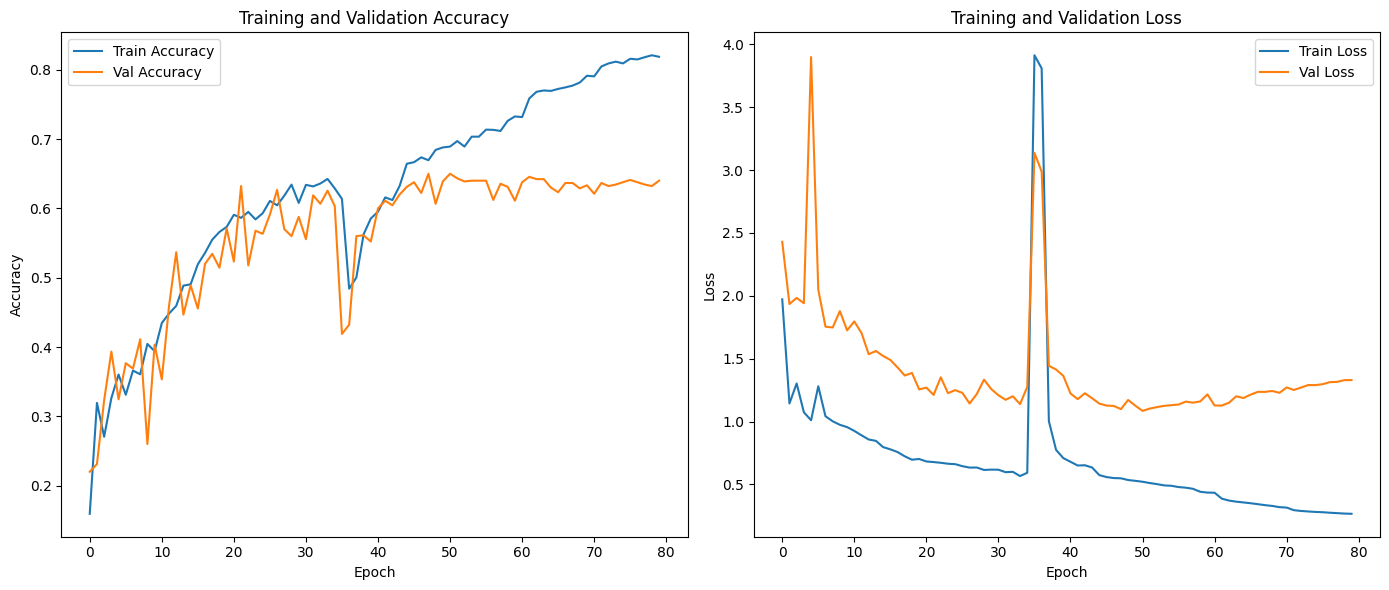

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# --- Accuracy Plot ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")

# --- Loss Plot ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")

plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import numpy as np

# === 1. Predict class probabilities and convert to class labels ===
Y_pred_probs = model.predict(X_test)
Y_pred_labels = np.argmax(Y_pred_probs, axis=1)

# === 2. Ground truth labels (already in Y_test2_array) ===
Y_true = Y_test2_array.astype(int)  # ensure it's integer type

# === 3. Accuracy ===
acc = accuracy_score(Y_true, Y_pred_labels)

# === 4. F1-Score (macro and weighted) ===
f1_macro = f1_score(Y_true, Y_pred_labels, average='macro')
f1_weighted = f1_score(Y_true, Y_pred_labels, average='weighted')

# === 5. Cohen's Kappa ===
kappa = cohen_kappa_score(Y_true, Y_pred_labels)

# === 6. Loss on test set ===
loss_fn = SparseCategoricalCrossentropy()
test_loss = loss_fn(Y_true, Y_pred_probs).numpy()

# === 7. Print results ===
print(f" Accuracy        : {acc:.4f}")
print(f" F1 Score (macro): {f1_macro:.4f}")
print(f" F1 Score (weighted): {f1_weighted:.4f}")
print(f" Cohen's Kappa   : {kappa:.4f}")
print(f" Test Loss       : {test_loss:.4f}")

 Accuracy        : 0.8675
 F1 Score (macro): 0.7743
 F1 Score (weighted): 0.8032
 Cohen's Kappa   : 0.8047
 Test Loss       : 0.3432


In [ ]:
# Run model on test set
y_pred_probs = model.predict(X_test)     # shape: (N, num_classes)

# Convert probabilities -> predicted class IDs
y_pred = np.argmax(y_pred_probs, axis=1)  # shape: (N,)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [ ]:
classes_with_ids = [
    (0, 'background'), (1, 'builtup'), (2, 'grassland'), (3, 'bare land'),
    (4, 'forest'), (5, 'shrubland'), (6, 'water body'), (7, 'wetland'),
    (8, 'permanent ice and snow'), (9, 'other crop'), (10, 'flower seeds'),
    (11, 'orchards'), (12, 'maize'), (13, 'wheat'), (14, 'rice')
]
class_names = [label for _, label in classes_with_ids]

In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix
import pandas as pd

# === Class definitions ===
classes_with_ids = [
    (0, 'background'), (1, 'builtup'), (2, 'grassland'), (3, 'bare land'),
    (4, 'forest'), (5, 'shrubland'), (6, 'water body'), (7, 'wetland'),
    (8, 'permanent ice and snow'), (9, 'other crop'), (10, 'flower seeds'),
    (11, 'orchards'), (12, 'maize'), (13, 'wheat'), (14, 'rice')
]
class_ids   = [c[0] for c in classes_with_ids]
class_names = [c[1] for c in classes_with_ids]

# === Collapse Y_test masks into single labels per patch ===
Y_test_labels = np.array([np.max(msk) for msk in Y_test])  # (450,)

# === Confusion Matrix ===
cm = confusion_matrix(Y_test_labels, y_pred, labels=class_ids)

# === Accuracy metrics ===
UA = np.diag(cm) / (cm.sum(axis=0) + 1e-9)   # User's accuracy (precision)
PA = np.diag(cm) / (cm.sum(axis=1) + 1e-9)   # Producer's accuracy (recall)
OA = np.trace(cm) / np.sum(cm)               # Overall accuracy

# === Put into DataFrame ===
results_df = pd.DataFrame({
    "Class ID": class_ids,
    "Class Name": class_names,
    "User's Acc (Precision)": UA,
    "Producer's Acc (Recall)": PA,
})


print("\nPer-Class Accuracy Table:")
print(results_df)

print("\nOverall Accuracy:", OA)

User's Accuracy (Precision):

Class ID   Class Name                Accuracy
0          background                0.0
1          builtup                   0.69
2          grassland                 0.5
3          bare land                 0.708696
4          forest                    0.653033
5          shrubland                 0.323171
6          water body                0.853659
7          wetland                   0.8841
8          permanent ice and snow    0.957
9          other crop                0.37
10         flower seeds              0.602379
11         orchards                  0.37
12         maize                     0.602385
13         wheat                     0.786111
14         rice                      0.692044

Producer's Accuracy (Recall):

Class ID   Class Name                Accuracy
0          background                0.0
1          builtup                   0.8285
2          grassland                 0.375
3          bare land                 0.608696
4        

User's Accuracy (Precision):

Class ID   Class Name                Accuracy
0          background                0.0
1          builtup                   0.69
2          grassland                 0.5
3          bare land                 0.708696
4          forest                    0.653033
5          shrubland                 0.323171
6          water body                0.853659
7          wetland                   0.8841
8          permanent ice and snow    0.957
9          other crop                0.37
10         flower seeds              0.602379
11         orchards                  0.37
12         maize                     0.602385
13         wheat                     0.786111
14         rice                      0.692044

Producer's Accuracy (Recall):

Class ID   Class Name                Accuracy
0          background                0.0
1          builtup                   0.8285
2          grassland                 0.375
3          bare land                 0.608696
4        

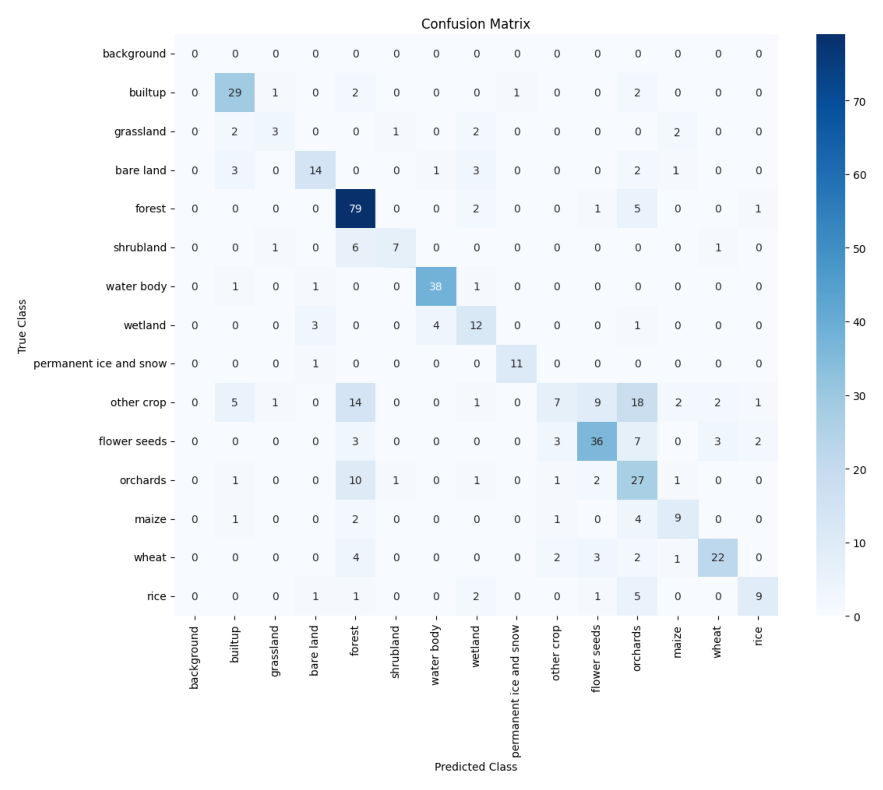

In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Class definitions ===
classes_with_ids = [
    (0, 'background'), (1, 'builtup'), (2, 'grassland'), (3, 'bare land'),
    (4, 'forest'), (5, 'shrubland'), (6, 'water body'), (7, 'wetland'),
    (8, 'permanent ice and snow'), (9, 'other crop'), (10, 'flower seeds'),
    (11, 'orchards'), (12, 'maize'), (13, 'wheat'), (14, 'rice')
]
class_ids   = [c[0] for c in classes_with_ids]
class_names = [c[1] for c in classes_with_ids]

# === Collapse Y_test masks into single labels per patch ===
Y_test_labels = np.array([np.max(msk) for msk in Y_test])  # (N,)

# === Confusion Matrix ===
cm = confusion_matrix(Y_test_labels, y_pred, labels=class_ids)

# === Accuracy metrics ===
UA = np.diag(cm) / (cm.sum(axis=0) + 1e-9)   # User's accuracy (precision)
PA = np.diag(cm) / (cm.sum(axis=1) + 1e-9)   # Producer's accuracy (recall)
OA = np.trace(cm) / np.sum(cm)               # Overall accuracy

# === Put into DataFrame ===
results_df = pd.DataFrame({
    "Class ID": class_ids,
    "Class Name": class_names,
    "User's Acc (Precision)": UA,
    "Producer's Acc (Recall)": PA,
})

print("\nPer-Class Accuracy Table:")
print(results_df)

print("\nOverall Accuracy:", OA)

# === Plot confusion matrix heatmap ===
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# **Prediction**

Loading model from: /content/drive/MyDrive/Patch8/SavedmodelResUnet++/resunet_epoch_80.h5


Big image shape: (6724, 6912, 23)
Total patches: 725760


Predicting: 100%|███████████████████████████████████████████████| 1418/1418 [02:38<00:00,  8.96it/s]


Classification map shape: (6724, 6912)


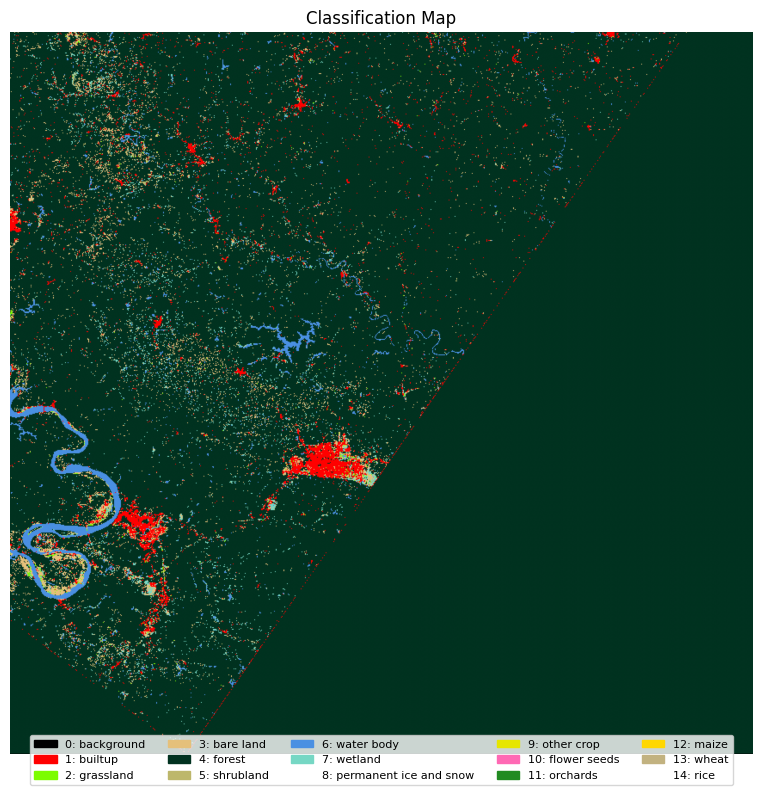

Unique class IDs present: [0 1 2 3 4 5 6 7]


In [ ]:
import os
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from tqdm import tqdm

# === Paths ===
big_image_path = "/content/drive/MyDrive/Images/BM05_01.tif"

# === Load big image ===
big_img = tiff.imread(big_image_path).astype(np.float32)   # (H, W, 23)
H, W, C = big_img.shape
print("Big image shape:", big_img.shape)

patch_size = 8

# === Collect patches and coords ===
patches, coords = [], []
for y in range(0, H - patch_size + 1, patch_size):
    for x in range(0, W - patch_size + 1, patch_size):
        patch = big_img[y:y+patch_size, x:x+patch_size, :]
        if patch.shape == (patch_size, patch_size, C):
            patches.append(patch)
            coords.append((y, x))

patches = np.array(patches)   # (N, 8, 8, 23)
print("Total patches:", patches.shape[0])

# === Predict in batches ===
batch_size = 128
pred_labels = []

for i in tqdm(range(0, len(patches), batch_size), desc="Predicting", ncols=100):
    batch = patches[i:i+batch_size]
    preds = model.predict(batch, verbose=0)   # (batch, num_classes)
    cls = np.argmax(preds, axis=-1)           # (batch,)
    pred_labels.extend(cls)

pred_labels = np.array(pred_labels)

# === Reconstruct classification map ===
class_map = np.zeros((H, W), dtype=np.uint8)
for (y, x), cls in zip(coords, pred_labels):
    class_map[y:y+patch_size, x:x+patch_size] = cls

print("Classification map shape:", class_map.shape)

# === Define classes and color map ===
classes_with_ids = [
    (0, 'background'), (1, 'builtup'), (2, 'grassland'), (3, 'bare land'),
    (4, 'forest'), (5, 'shrubland'), (6, 'water body'), (7, 'wetland'),
    (8, 'permanent ice and snow'), (9, 'other crop'), (10, 'flower seeds'),
    (11, 'orchards'), (12, 'maize'), (13, 'wheat'), (14, 'rice')
]

color_map = {
    0:  '#000000', 1:  '#ff0000', 2:  '#7CFC00', 3:  '#e5c07b',
    4:  '#013220', 5:  '#BDB76B', 6:  '#4a90e2', 7:  '#76d7c4',
    8:  '#ffffff', 9:  '#e6e600', 10: '#ff69b4', 11: '#228B22',
    12: '#ffd700', 13: '#c2b280', 14: '#ffffff'
}

# Build colormap
cmap = mcolors.ListedColormap([color_map[i] for i, _ in classes_with_ids])
bounds = list(color_map.keys()) + [max(color_map.keys()) + 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# === Plot classification map ===
plt.figure(figsize=(10, 8))
plt.imshow(class_map, cmap=cmap, norm=norm)
plt.title("Classification Map")
plt.axis("off")

# Legend
handles = [mpatches.Patch(color=color_map[i], label=f"{i}: {name}")
           for i, name in classes_with_ids]
plt.legend(handles=handles, loc="lower center", ncol=5,
           fontsize=8, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

# === Unique classes present ===
unique_classes = np.unique(class_map)
print("Unique class IDs present:", unique_classes)


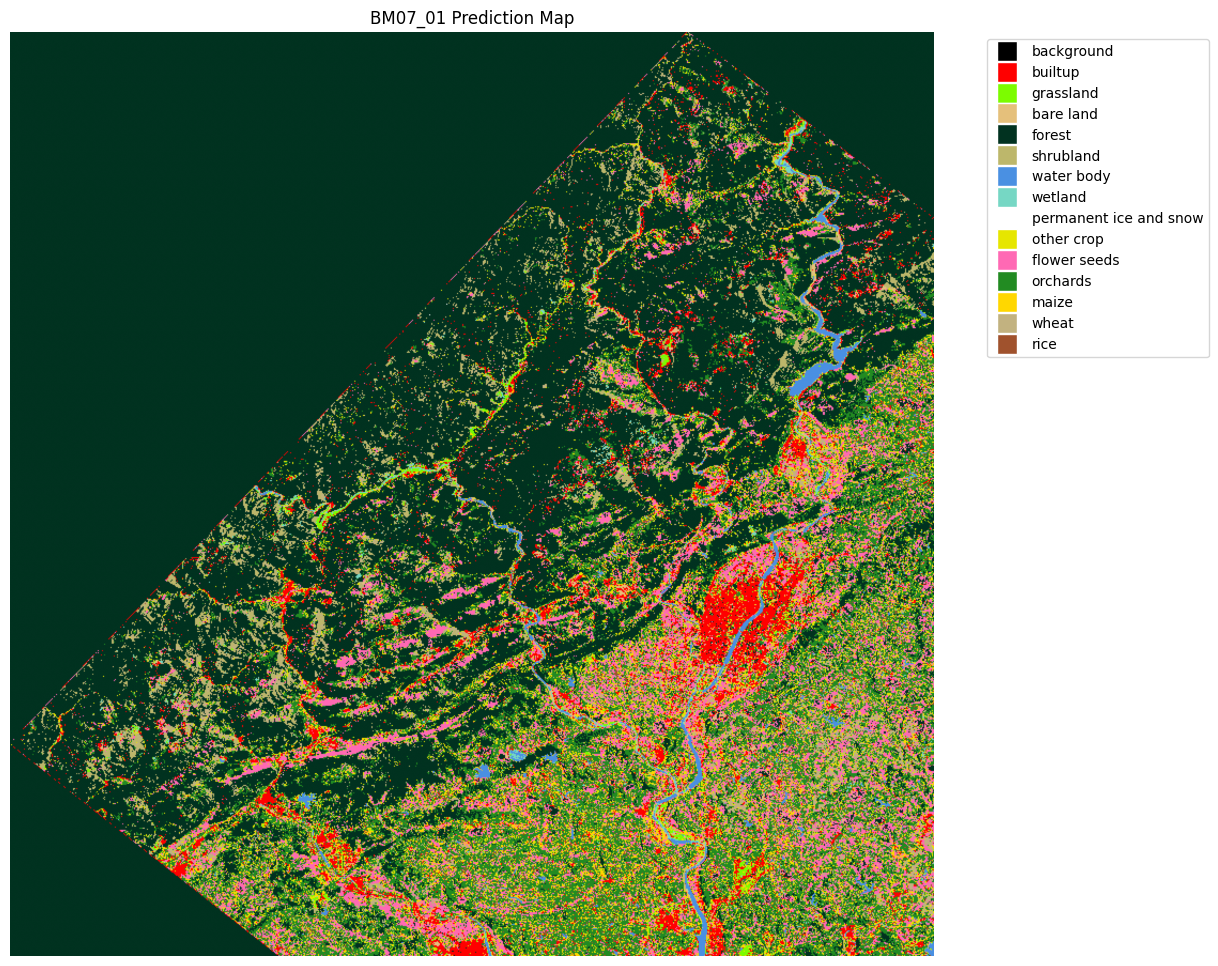

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Path to your TIFF file
tiff_path = "/content/drive/MyDrive/PredictedMaps/BM07_01_prediction.tif"

# Classes and color map
classes_with_ids = [
    (0, 'background'), (1, 'builtup'), (2, 'grassland'), (3, 'bare land'),
    (4, 'forest'), (5, 'shrubland'), (6, 'water body'), (7, 'wetland'),
    (8, 'permanent ice and snow'), (9, 'other crop'), (10, 'flower seeds'),
    (11, 'orchards'), (12, 'maize'), (13, 'wheat'), (14, 'rice')
]

color_map = {
    0:  '#000000', 1:  '#ff0000', 2:  '#7CFC00', 3:  '#e5c07b',
    4:  '#013220', 5:  '#BDB76B', 6:  '#4a90e2', 7:  '#76d7c4',
    8:  '#ffffff', 9:  '#e6e600', 10: '#ff69b4', 11: '#228B22',
    12: '#ffd700', 13: '#c2b280', 14: '#a0522d'
}

# Read the TIFF
with rasterio.open(tiff_path) as src:
    img = src.read(1)  # assuming single band classification

# Create a colormap in the same order as class IDs
cmap = ListedColormap([color_map[i] for i, _ in classes_with_ids])

# Plot the classified map
plt.figure(figsize=(12, 12))
im = plt.imshow(img, cmap=cmap, vmin=0, vmax=len(classes_with_ids)-1)
plt.axis('off')
plt.title("BM07_01 Prediction Map")

# Create a custom legend
handles = [plt.Line2D([0], [0], marker='s', color='w', label=name,
                      markerfacecolor=color_map[i], markersize=15)
           for i, name in classes_with_ids]
plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
